# ft_linear_regression — visualisation

The plots are the ones from **Course 1 Week 1** of the Machine Learning Specialization
(`C1_W1_Lab04_Cost_function`, `C1_W1_Lab05_Gradient_Descent`), copied into `plot_utils.py`
and rewired so that **every number is computed by the C code in `src/`**, never by a Python
reimplementation.

| plot | C function behind it |
|---|---|
| data before / after normalisation | `dataset_load`, `z_score_normalisation` |
| best fit line | `compute_gradient`, `linreg_predict`, `weight_and_bias_denormalize` |
| cost contour + 3D soup bowl | `squared_error_cost` |
| model quality | `r_squared` |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import ml_c
import plot_utils as pu

get_ipython().run_line_magic('matplotlib', 'inline')
get_ipython().run_line_magic('config', "InlineBackend.figure_format = 'retina'")

pu.use_lab_style()
ml_c.build()          # compiles libml.dylib from src/*.c when needed
ml_c.load()           # ctypes bindings
print('C library:', ml_c.LIB_PATH)

libml.dylib up to date
C library: /Users/sofiahuppertz/Desktop/ft_linear_regression/libml.dylib


## 2. The data, read by the C parser

`dataset_load` is the exact CSV reader `train.c` uses: header line skipped, malformed rows dropped.

In [2]:
x_raw, y_train = ml_c.dataset_load(ml_c.DATA_CSV)
print(f'{len(x_raw)} samples')
print('km   :', x_raw[:5])
print('price:', y_train[:5])

24 samples
km   : [240000. 139800. 150500. 185530. 176000.]
price: [3650. 3800. 4400. 4450. 5250.]


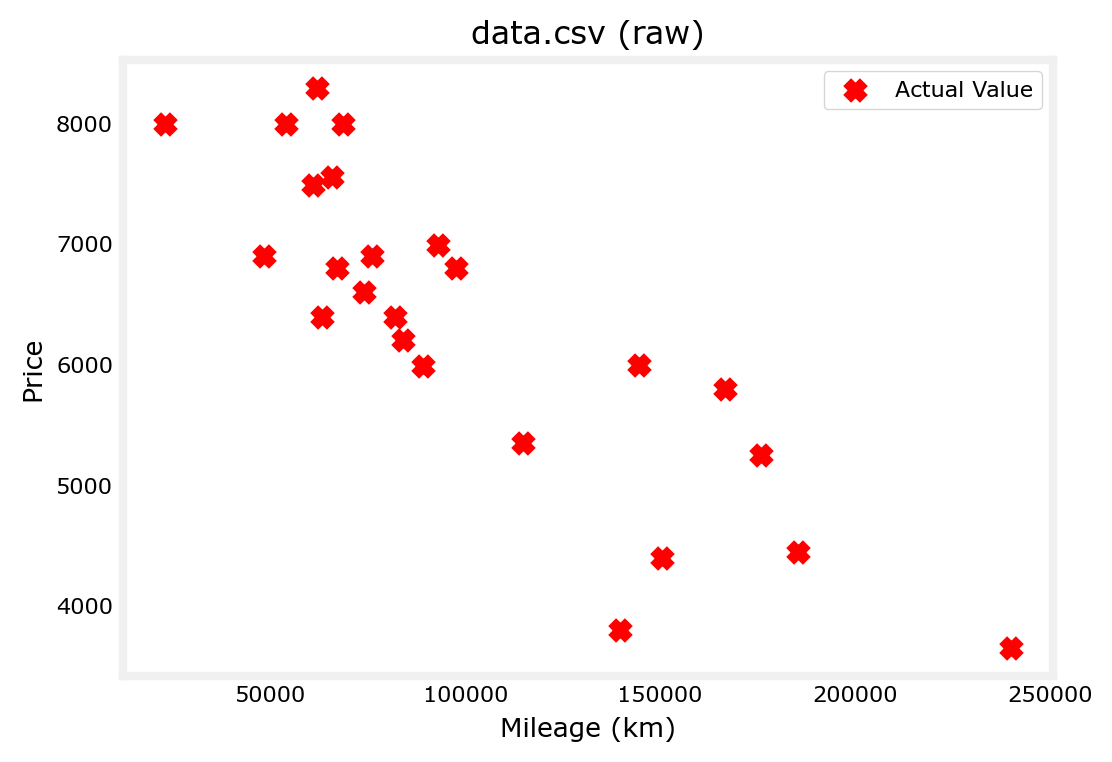

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
pu.plt_data(x_raw, y_train, ax=ax, title='data.csv (raw)')
pu.save(fig, '01_data_raw')
plt.show()

## 3. Before / after normalisation

`z_score_normalisation` rewrites the feature in place as $x' = (x - \mu)/\sigma$ and returns the
`scaling` struct. The cloud keeps its shape; only the x axis changes — but that is what lets
gradient descent converge with a sane learning rate (section 9 shows why).

mean   = 101066.2500
spread = 51565.1899
x_norm : [2.6943 0.7512 0.9587 1.638  1.4532]


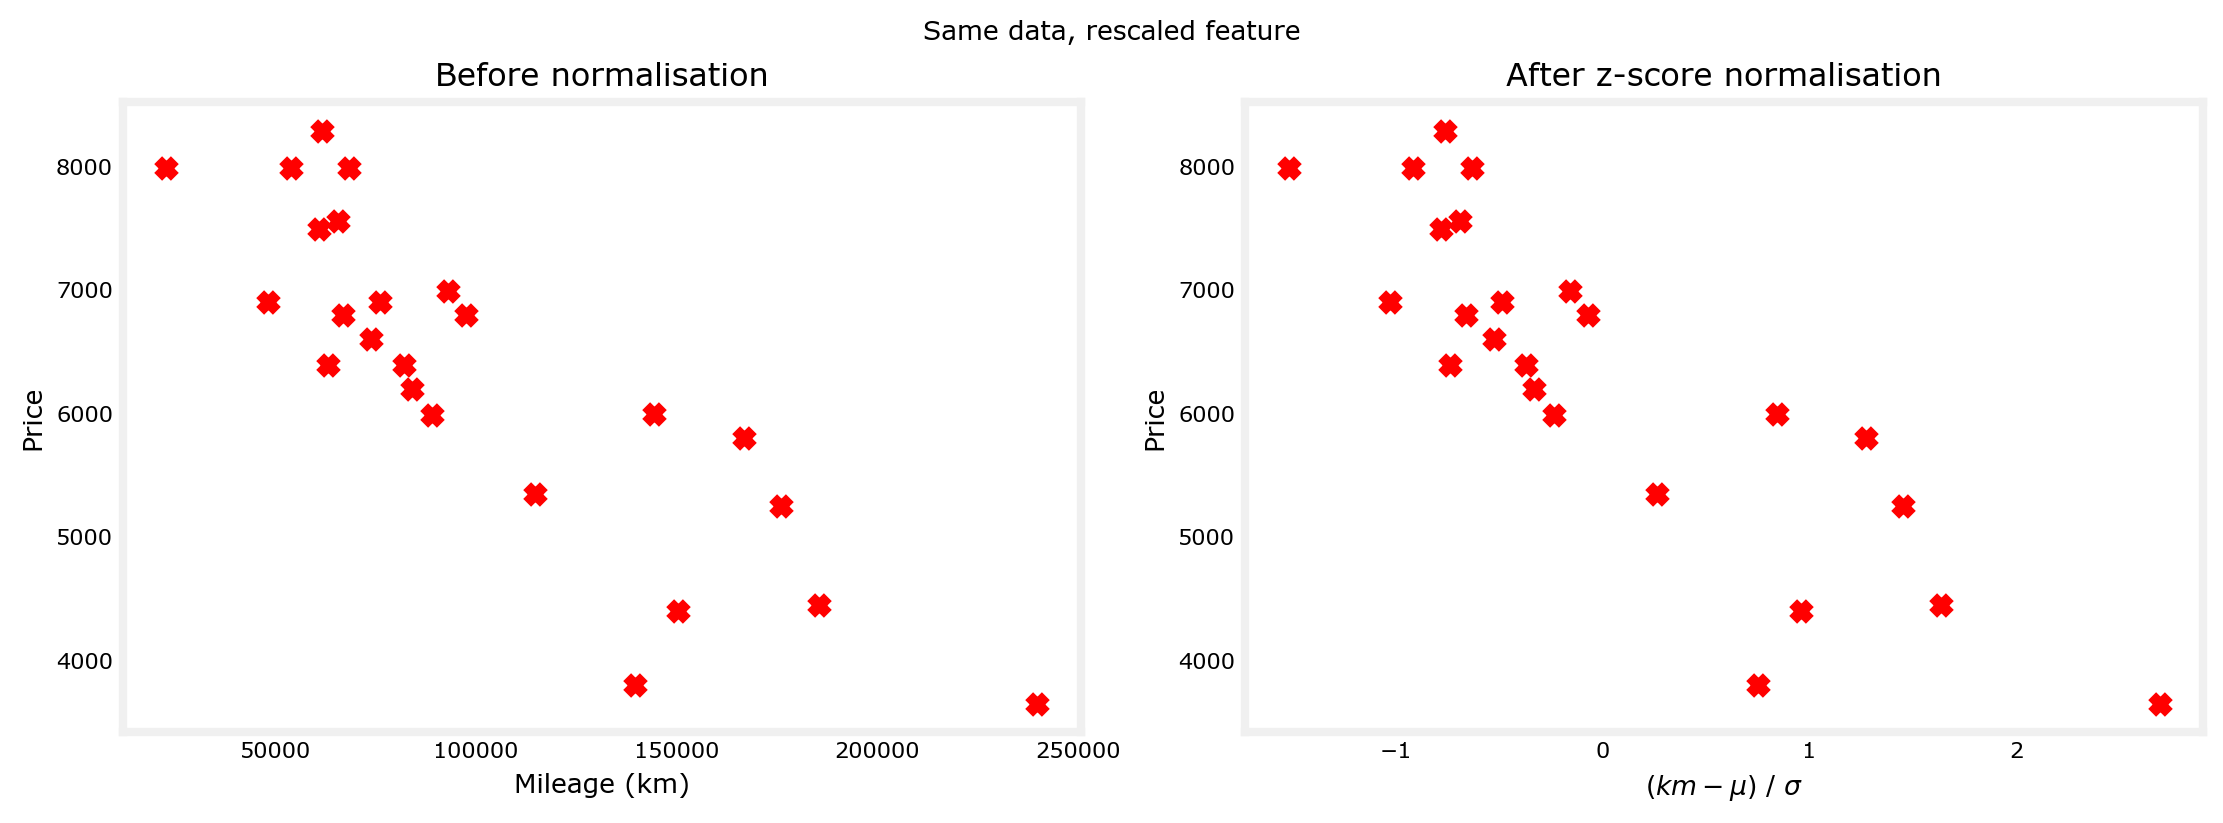

In [4]:
x_train, scaling = ml_c.z_score_normalisation(x_raw)
print(f'mean   = {scaling.mean:.4f}')
print(f'spread = {scaling.spread:.4f}')
print('x_norm :', np.round(x_train[:5], 4))

fig, ax = pu.plt_normalisation(x_raw, x_train, y_train)
pu.save(fig, '02_normalisation')
plt.show()

## 4. Training

`ml_c.gradient_descent_history` runs the loop of `src/gradient_descent.c` one iteration at a time,
calling the C `compute_gradient` and `squared_error_cost` at each step, so the cost history and the
$(w, b)$ path stay available for the plots below. The one-shot C loop is there too as
`ml_c.gradient_descent(...)` — it just prints a line per iteration, like `./train`.

In [5]:
w_init, b_init = 0.0, 0.0
learning_rate, iterations, patience = 0.1, 5000, 50

w_norm, b_norm, j_hist, p_hist = ml_c.gradient_descent_history(
    x_train, y_train, w_init, b_init, learning_rate, iterations, patience)

print(f'\nnormalised space : w = {w_norm:.6f}, b = {b_norm:.6f}')

theta1, theta0 = ml_c.weight_and_bias_denormalize(w_norm, b_norm, scaling)
print(f'raw space        : theta1 (w) = {theta1:.10f}, theta0 (b) = {theta0:.6f}')

saved_w, saved_b, ok = ml_c.weight_and_bias_load(ml_c.VARIABLES_CSV)
print(f'variables.csv    : theta1 (w) = {saved_w:.10f}, theta0 (b) = {saved_b:.6f}  (found={ok})')

Iteration    0: cost 1.6956e+07  dj_dw  1.106e+03  dj_db -6.332e+03  w -1.10602e+02  b  6.33183e+02
Iteration   10: cost 2.2571e+06  dj_dw  3.856e+02  dj_db -2.208e+03  w -7.58939e+02  b  4.34484e+03
Iteration   20: cost 4.7015e+05  dj_dw  1.345e+02  dj_db -7.698e+02  w -9.85000e+02  b  5.63901e+03
Iteration   30: cost 2.5289e+05  dj_dw  4.689e+01  dj_db -2.684e+02  w -1.06382e+03  b  6.09026e+03
Iteration   40: cost 2.2648e+05  dj_dw  1.635e+01  dj_db -9.359e+01  w -1.09131e+03  b  6.24760e+03
Iteration   50: cost 2.2327e+05  dj_dw  5.700e+00  dj_db -3.263e+01  w -1.10089e+03  b  6.30246e+03
Iteration   60: cost 2.2288e+05  dj_dw  1.988e+00  dj_db -1.138e+01  w -1.10423e+03  b  6.32159e+03
Iteration   70: cost 2.2283e+05  dj_dw  6.930e-01  dj_db -3.967e+00  w -1.10540e+03  b  6.32826e+03
Iteration   80: cost 2.2282e+05  dj_dw  2.416e-01  dj_db -1.383e+00  w -1.10580e+03  b  6.33059e+03
Iteration   90: cost 2.2282e+05  dj_dw  8.425e-02  dj_db -4.823e-01  w -1.10594e+03  b  6.33140e+03


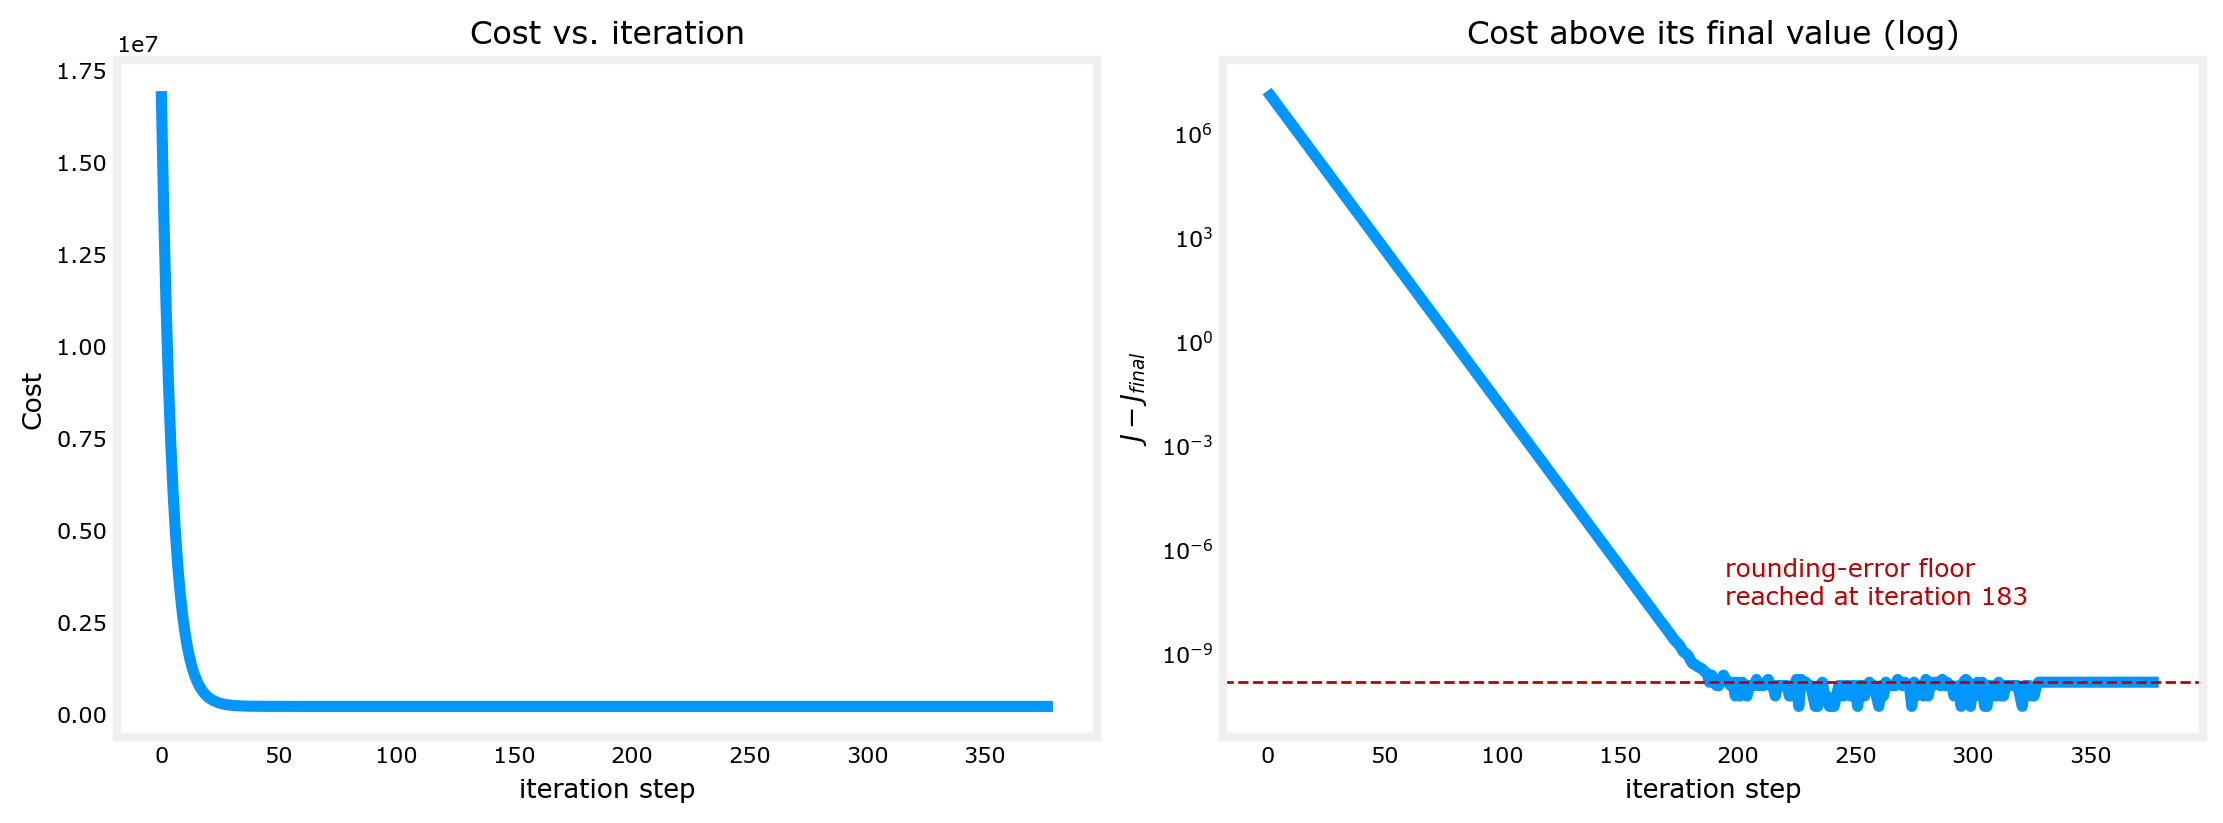

In [6]:
fig, ax = pu.plt_convergence(j_hist)
pu.save(fig, '03_convergence')
plt.show()

## 5. The best fit line

Predictions come from the C `linreg_predict`, so this is literally the line `./predict` answers with.

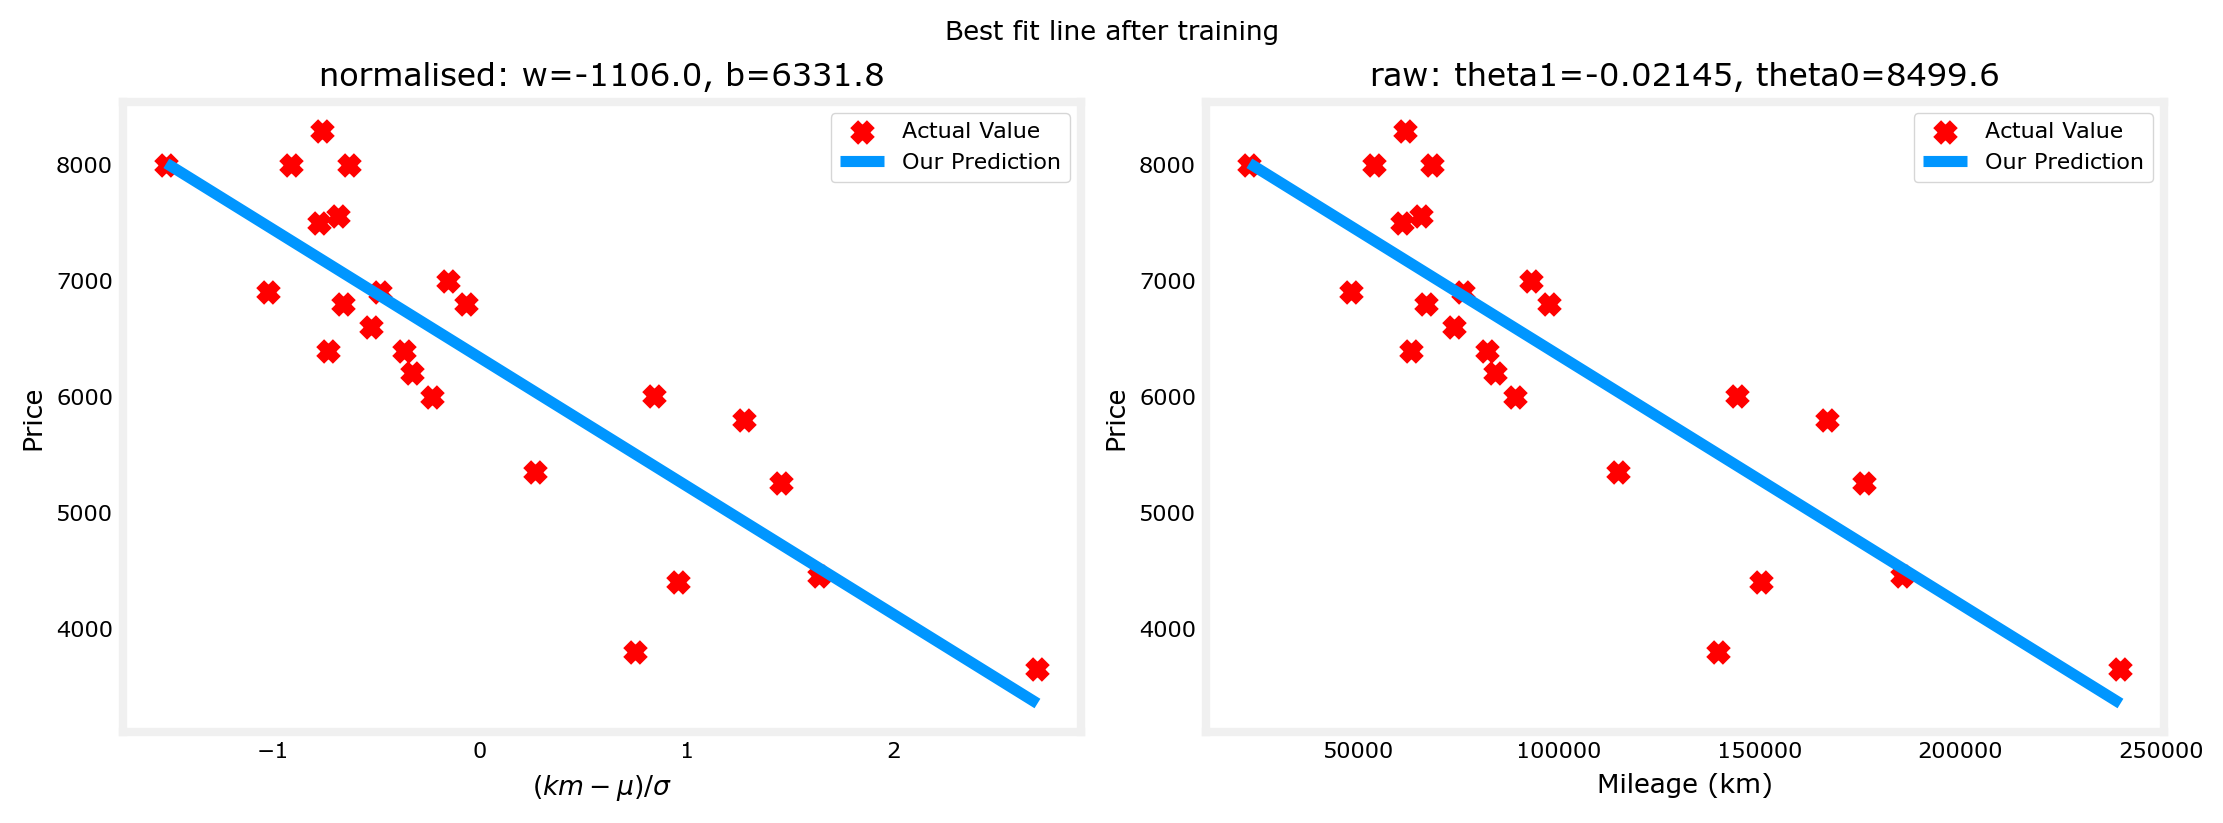

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

f_wb_norm = ml_c.predict(x_train, w_norm, b_norm)
pu.plt_data(x_train, y_train, f_wb=f_wb_norm, ax=ax[0],
            title=f'normalised: w={w_norm:.1f}, b={b_norm:.1f}',
            xlabel=r'$(km-\mu)/\sigma$')

f_wb_raw = ml_c.predict(x_raw, theta1, theta0)
pu.plt_data(x_raw, y_train, f_wb=f_wb_raw, ax=ax[1],
            title=f'raw: theta1={theta1:.5f}, theta0={theta0:.1f}')

fig.suptitle('Best fit line after training')
pu.save(fig, '04_best_fit_line')
plt.show()

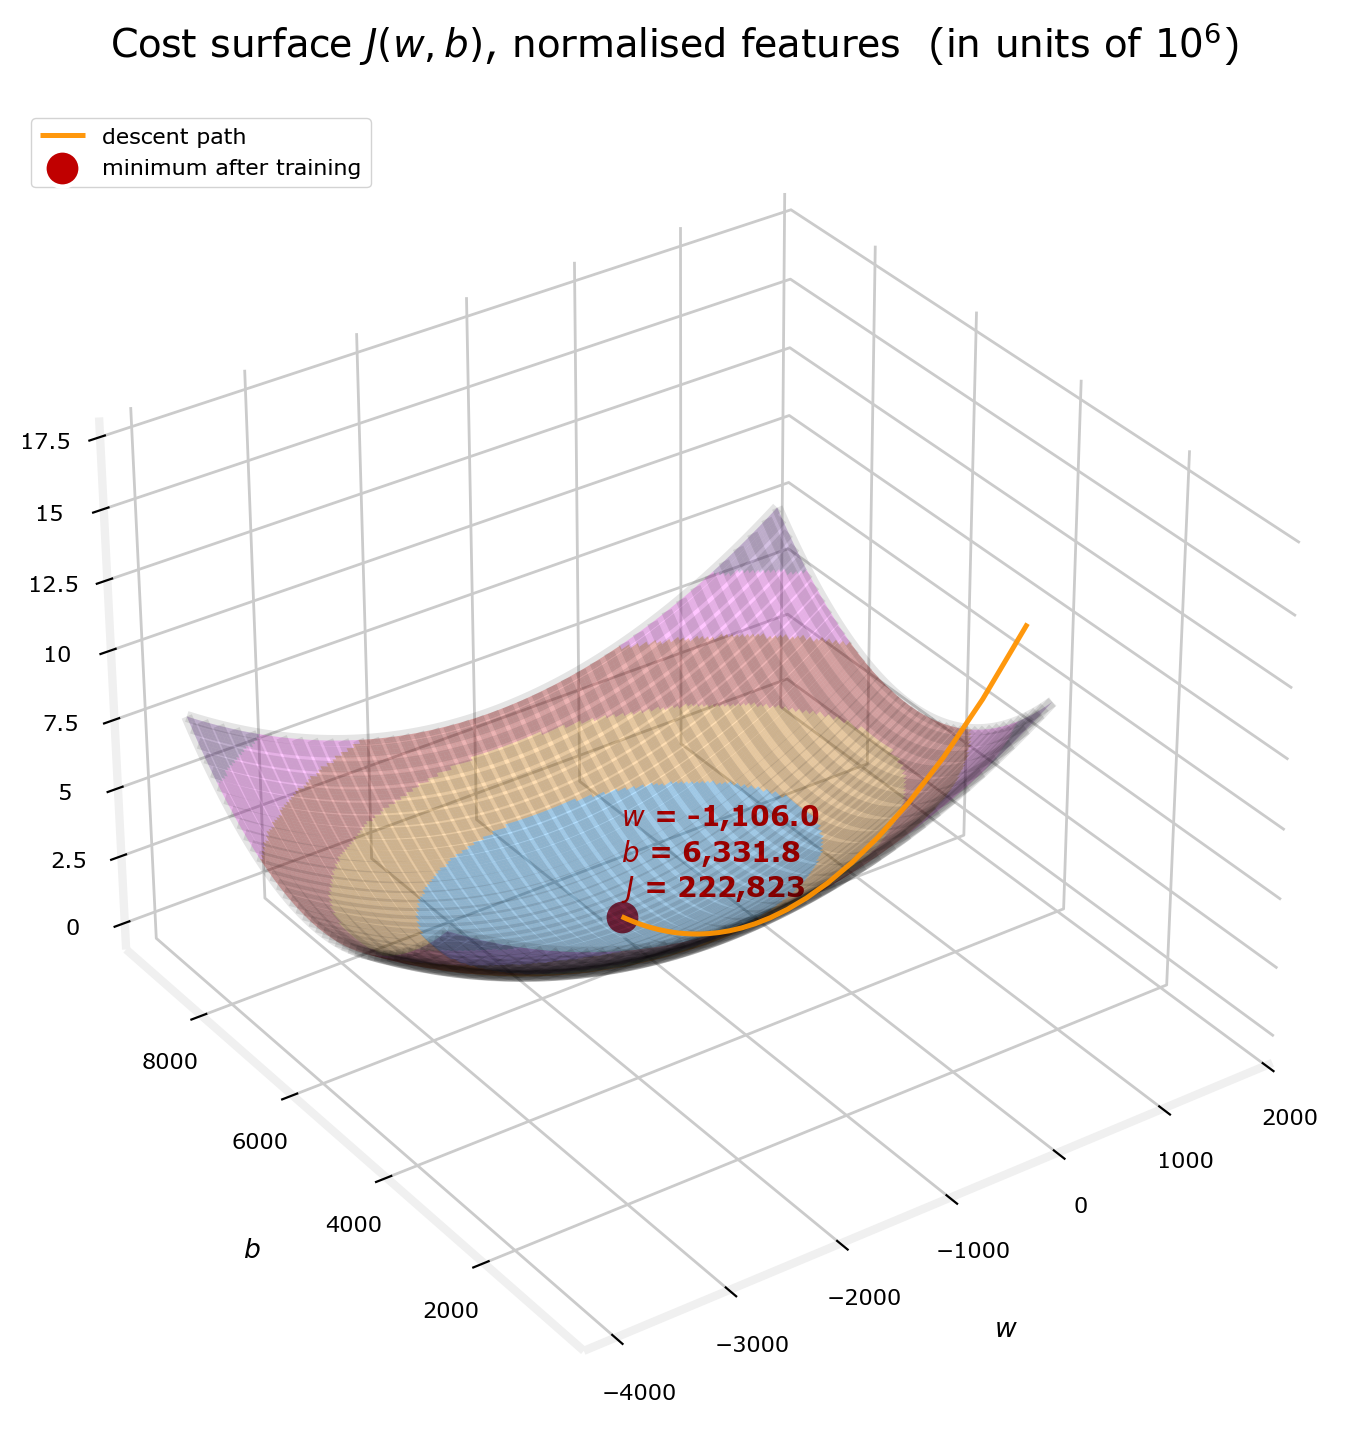

In [8]:
plt.close('all')
fig, ax = pu.plt_cost_surface(x_train, y_train, w_norm, b_norm, p_hist=p_hist)
pu.save(fig, '05_cost_surface')
plt.show()

## 7. The descent path on the contour

`plt_contour_wgrad` draws the 1000 steps stored in `p_hist` as arrows walking down to the minimum.

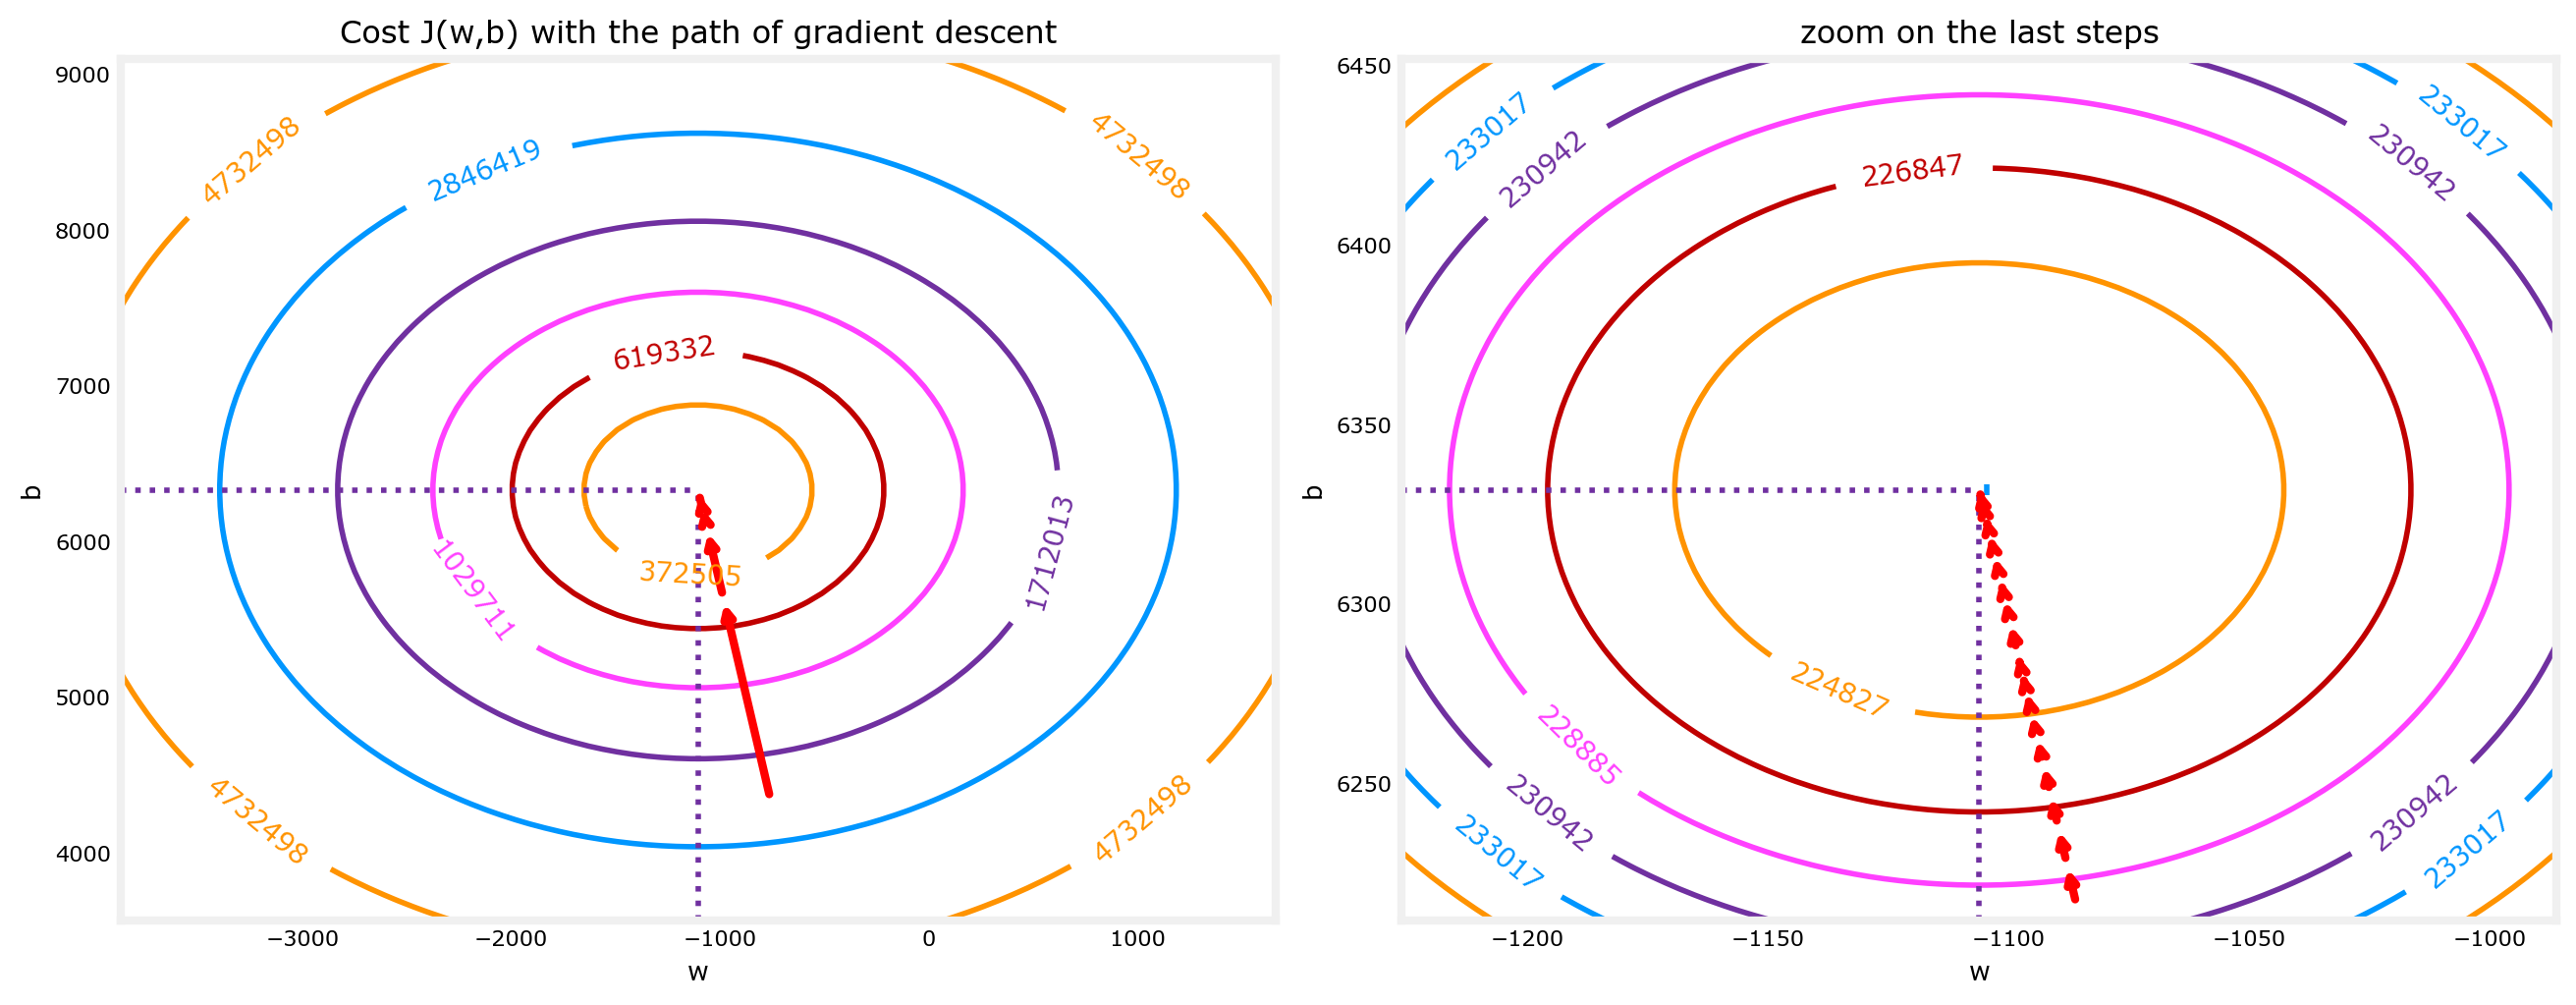

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
pu.plt_contour_wgrad(x_train, y_train, p_hist, ax=ax[0],
                     w_final=w_norm, b_final=b_norm, step=10)
pu.plt_contour_wgrad(x_train, y_train, p_hist, ax=ax[1],
                     w_range=np.linspace(w_norm - 120, w_norm + 120, 80),
                     b_range=np.linspace(b_norm - 120, b_norm + 120, 80),
                     w_final=w_norm, b_final=b_norm, step=1)
ax[1].set_title('zoom on the last steps')
pu.save(fig, '06_contour_descent_path')
plt.show()

## 10. Model quality: $R^2$

$R^2$ measures how much of the variance in price the model accounts for.

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
     = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

$SS_{tot}$ is the total variation in price: how far each car sits from the mean price (left panel).
Divided by $m$ that is exactly $\mathrm{Var}(y)$.

$SS_{res}$ is the variation still there after the model has spoken - the residuals, the vertical
gaps between each car and the line (middle panel).

Their ratio $SS_{res}/SS_{tot}$ is therefore **the fraction of the variance that remains
unexplained**, and $R^2$ is one minus it: the fraction the model does explain. The $m$ cancels in
the ratio, so this is a statement about variance, not about how many cars are in the file.

$R^2 = 1$ would mean no residual variance at all - every point exactly on the line. $R^2 = 0$ means
the residual variance equals the total: knowing the mileage narrowed nothing down. Negative values
are possible and mean the line leaves *more* variance than there was to begin with.

The value comes from the C `r_squared`, the predictions from `linreg_predict`. The right panel
replays `p_hist` through `r_squared`, so it is the same curve `./train` prints while it runs.

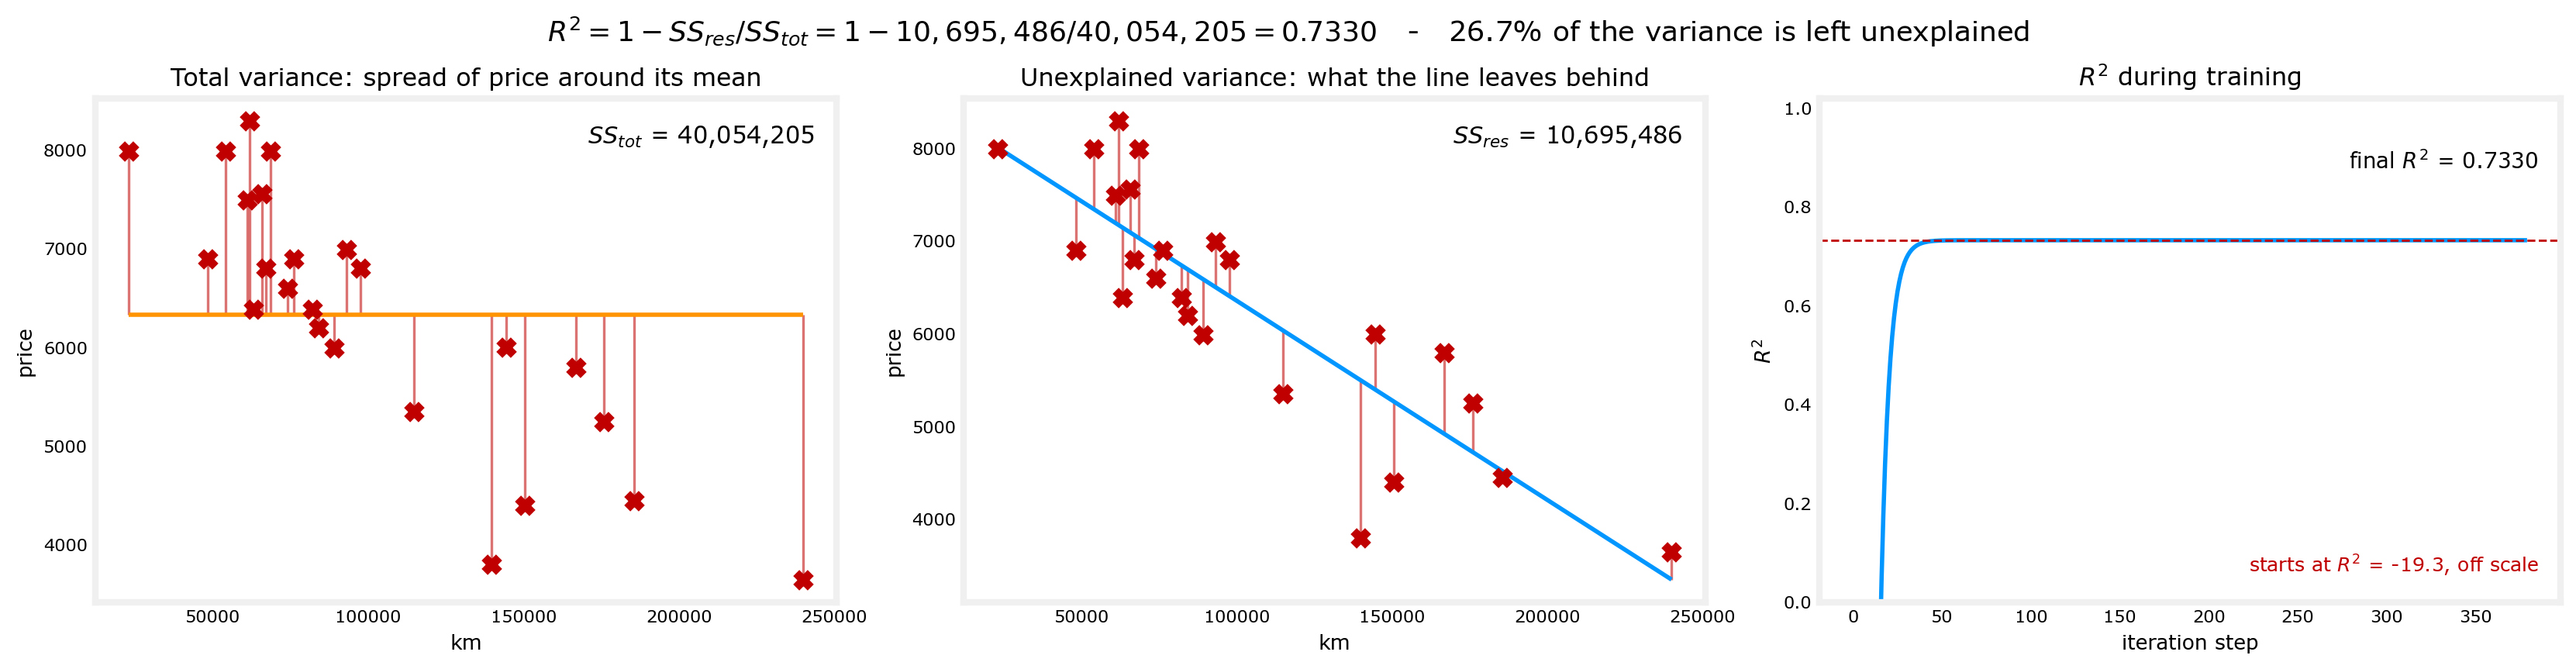

R^2 (raw km)        = 0.732975
R^2 (normalised km) = 0.732975
identical: R^2 does not depend on the units of x


In [10]:
# p_hist lives in normalised space; map each step back so every panel is in raw km
p_raw = np.array([ml_c.weight_and_bias_denormalize(wi, bi, scaling) for wi, bi in p_hist])

fig, ax = pu.plt_r_squared(x_raw, y_train, theta1, theta0, p_hist=p_raw)
pu.save(fig, '07_r_squared')
plt.show()

print(f'R^2 (raw km)        = {ml_c.r_squared(x_raw, y_train, theta1, theta0):.6f}')
print(f'R^2 (normalised km) = {ml_c.r_squared(x_train, y_train, w_norm, b_norm):.6f}')
print('identical: R^2 does not depend on the units of x')